In [2]:
# LAB 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris


In [2]:
#Load data more than 2 dimensions
# Iris dataset has 4 dimensions
data = load_iris()
X = data.data
y = data.target

# import dataset using keras 
from keras.datasets import mnist
#(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [9]:
#2. Find the 2 principal components using PCA from sklearn
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("Original shape:", X.shape)
print("Transformed shape:", X_pca.shape)

Original shape: (150, 4)
Transformed shape: (150, 2)


Original shape: (150, 4)
Transformed shape with 95% variance: (150, 2)


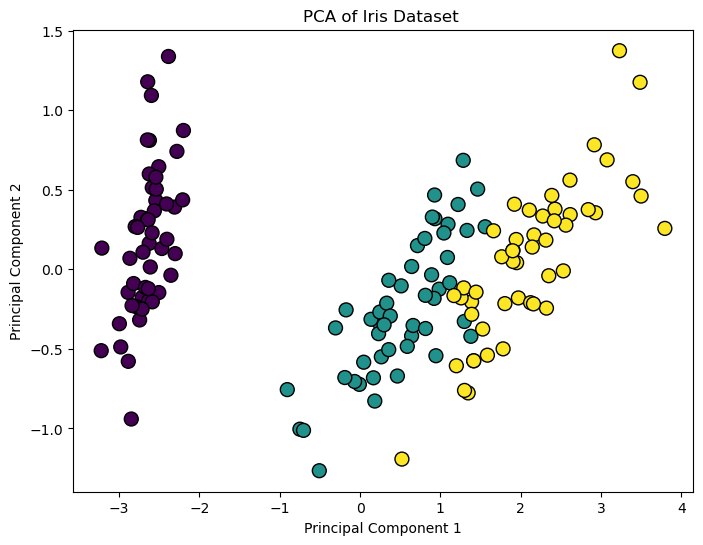

In [ ]:
#3 Practice Using PCA to preserve variance
pca_percent = PCA(n_components=0.93) # Change the components to preserve desired variance
X_pca_95 = pca_percent.fit_transform(X)
print("Original shape:", X.shape)
print("Transformed shape with 95% variance:", X_pca_95.shape)

 # Visualize the 2D PCA result
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca_95[:,0], X_pca_95[:,1], c=y,
                        cmap='viridis', edgecolor='k', s=100)
plt.title('PCA of Iris Dataset ')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

Accuracy with original data: 0.9333333333333333


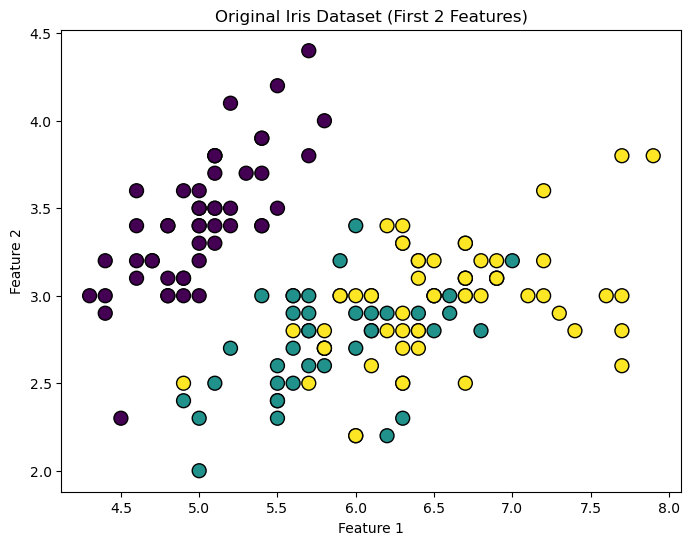

In [ ]:
#4 Train a classification of regression neural network using: 
# a) Original data
# b) Principal components

# Original data
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
X_train_minist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(X, y, test_size=0.2, random_state=42)
mlp_original = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)
mlp_original.fit(X_train_minist, y_train_mnist)
accuracy_original = mlp_original.score(X_test_mnist, y_test_mnist)
print("Accuracy with original data:", accuracy_original)

# Visualize original data 
plt.figure(figsize=(8,6))
scatter = plt.scatter(X[:,0], X[:,1], c=y,
                        cmap='viridis', edgecolor='k', s=100)
plt.title('Original Iris Dataset (First 2 Features)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
# PCA without using sklearn
def pca_manual(X, n_components):
    # Center the data
    X_centered = X - np.mean(X, axis=0)
    
    # Compute covariance matrix
    covariance_matrix = np.cov(X_centered, rowvar=False) # sklearn uses rowvar=False by default
    
    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix) # sklearn uses svd decomposition but eigh is fine here for covariance matrix. symmetric matrix importantly. 
    
    # Sort eigenvalues and eigenvectors
    sorted_indices = np.argsort(eigenvalues)[::-1]  # Descending order here, sklearn order by variance
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    
    # Select top n_components
    selected_eigenvectors = sorted_eigenvectors[:, :n_components]
    
    # Transform data
    X_reduced = np.dot(X_centered, selected_eigenvectors) # eqivalent to pca.fit_transform(X) in sklearn
    
    return X_reduced

Accuracy with PCA reduced data: 0.9666666666666667


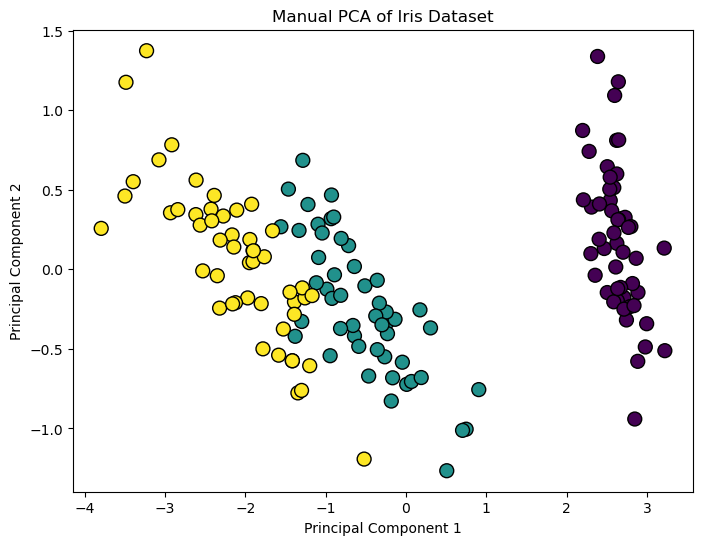

In [ ]:
# use manual PCA and visualize
X_pca_manual = pca_manual(X, n_components=2)
X_train_pca, X_test_pca, y_train_mnist, y_test_mnist = train_test_split(X_pca_manual, y, test_size=0.2, random_state=42)
mlp_pca = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)
mlp_pca.fit(X_train_pca, y_train_mnist)
accuracy_pca = mlp_pca.score(X_test_pca, y_test_mnist)
print("Accuracy with PCA reduced data:", accuracy_pca)

# Visualize PCA manual result
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca_manual[:,0], X_pca_manual[:,1], c=y, cmap='viridis', edgecolor='k', s=100)
plt.title('Manual PCA of Iris Dataset')
plt.xlabel('Principal Component 1') 
plt.ylabel('Principal Component 2')
plt.show()

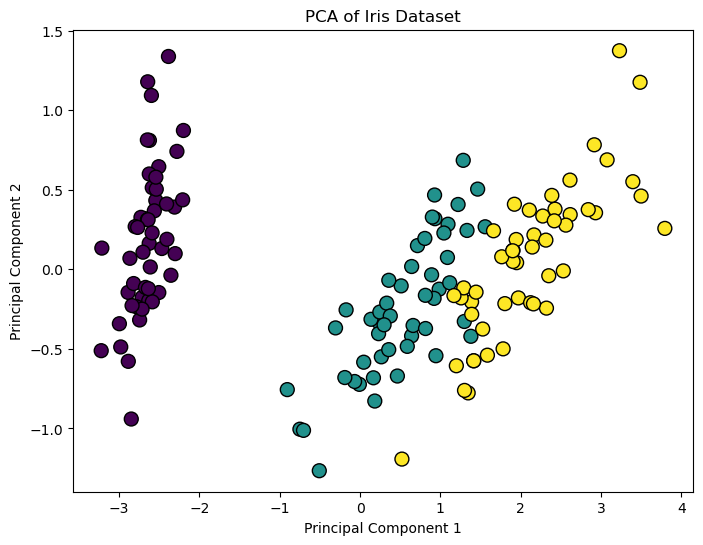

Accuracy with original data: 0.93
Accuracy with PCA data: 0.97


In [ ]:
# Princiapll components using sklearn PCA
X_train_pca, X_test_pca, y_train_mnist, y_test_mnist = train_test_split(X_pca, y, test_size=0.2, random_state=42)
mlp_pca = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)
mlp_pca.fit(X_train_pca, y_train_mnist)
accuracy_pca = mlp_pca.score(X_test_pca, y_test_mnist)
#print("Accuracy with PCA data:", accuracy_pca)

# Visualize PCA data
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y,
                        cmap='viridis', edgecolor='k', s=100)
plt.title('PCA of Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

#5 Compare the results and discuss
print(f"Accuracy with original data: {accuracy_original:.2f}")
print(f"Accuracy with PCA data: {accuracy_pca:.2f}")

# The accuracy may vary based on the random state and model parameters.
# In this case, we can see how dimensionality reduction via PCA affects the performance of a neural network classifier.

Accuracy with Kernel PCA (linear kernel): 0.97


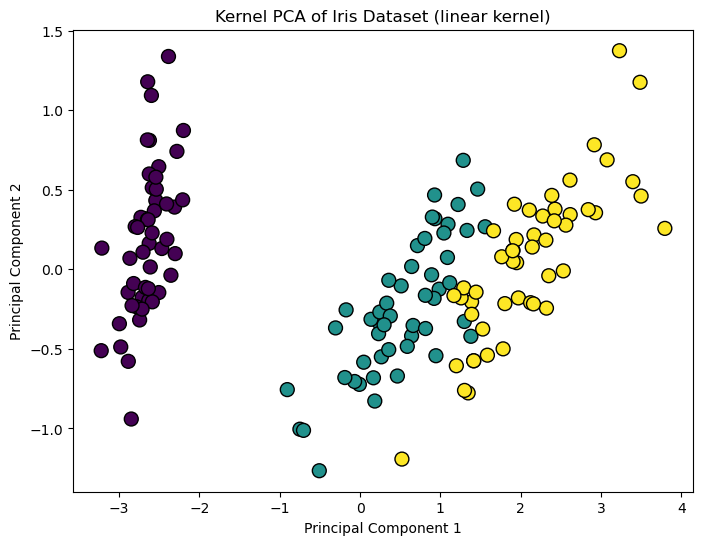

Accuracy with Kernel PCA (sigmoid kernel): 0.37


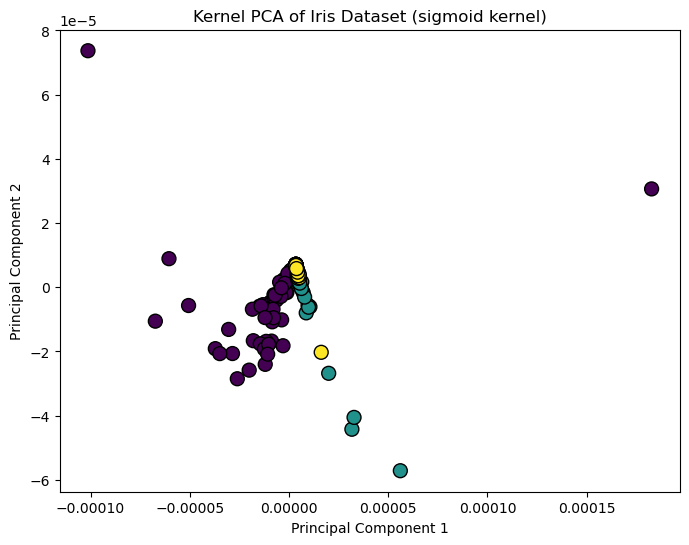

Accuracy with Kernel PCA (rbf kernel): 0.97


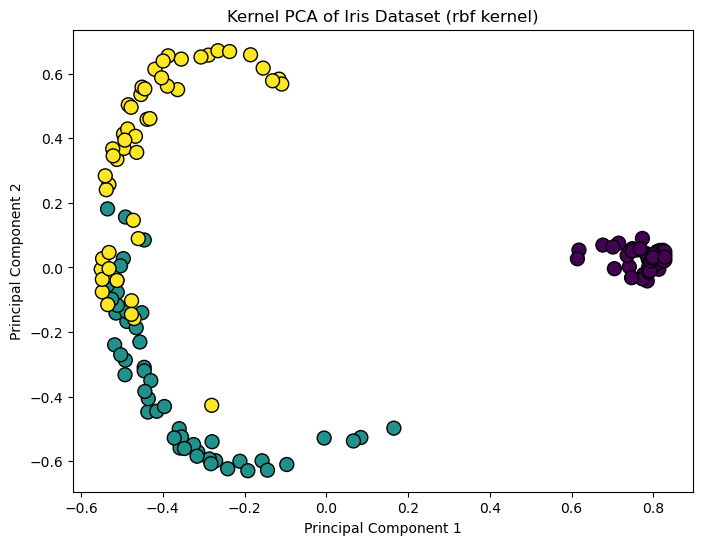

In [ ]:
# Repeat part 4 using Kernel PCA with different kernels (linear, polynomial, RBF). 
from sklearn.decomposition import KernelPCA
kernels = ['linear', 'sigmoid', 'rbf']
for kernel in kernels:
    kpca = KernelPCA(n_components=2, kernel=kernel)
    X_kpca = kpca.fit_transform(X)
    
    X_train_kpca, X_test_kpca, y_train_mnist, y_test_mnist = train_test_split(X_kpca, y, test_size=0.2, random_state=42)
    mlp_kpca = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)
    mlp_kpca.fit(X_train_kpca, y_train_mnist)
    accuracy_kpca = mlp_kpca.score(X_test_kpca, y_test_mnist)
    
    print(f"Accuracy with Kernel PCA ({kernel} kernel): {accuracy_kpca:.2f}")
    
    # Visualize Kernel PCA data
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_kpca[:,0], X_kpca[:,1], c=y,
                            cmap='viridis', edgecolor='k', s=100)
    plt.title(f'Kernel PCA of Iris Dataset ({kernel} kernel)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

In [12]:
# 6- Build a pipeline to tune the hyperparameters of Kernel PCA and also the neural network. 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.neural_network import MLPClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kpca', KernelPCA(fit_inverse_transform=False)),
    ('mlp', MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=42
    ))
])

param_grid = {
    # Kernel PCA
    'kpca__n_components': [1, 2, 3],
    'kpca__kernel': ['linear', 'rbf', 'sigmoid'],
    'kpca__gamma': [0.01, 0.1, 1],  # needed for rbf & sigmoid

    # MLP
    'mlp__hidden_layer_sizes': [(5,), (10, 10), (20, 10)],
    'mlp__alpha': [0.0001, 0.001, 0.01]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)


#Which hyperparameters can be tuned?
# Hyperparameters that can be tuned include:
# - Number of components in Kernel PCA
# - Kernel type in Kernel PCA (linear, polynomial, RBF, sigmoid)
# - Gamma parameter in Kernel PCA (for RBF and sigmoid kernels)
# MLP Classifier:
# - Hidden layer sizes in the neural network
# - Regularization parameter (alpha) in the neural network


Best parameters found: {'kpca__gamma': 0.01, 'kpca__kernel': 'linear', 'kpca__n_components': 2, 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (5,)}
Best cross-validation score: 0.6399999999999999


## Classification Problem

In [ ]:
# Imports
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, MaxPooling2D, Conv2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import keras_tuner as kt

In [158]:
# ------------------------
# Load and preprocess Fashion-MNIST
# ------------------------
(X_train_minist, y_train_mnist), (X_test_mnist, y_test_mnist) = fashion_mnist.load_data()

# Normalize
X_train_minist = X_train_minist.astype('float32') / 255.0
X_test_mnist  = X_test_mnist.astype('float32') / 255.0

# Reshape
X_train_minist = X_train_minist.reshape(-1,28,28,1)
X_test_mnist  = X_test_mnist.reshape(-1,28,28,1)

# One-hot encode
y_train_mnist = tf.keras.utils.to_categorical(y_train_mnist, 10)
y_test_mnist  = tf.keras.utils.to_categorical(y_test_mnist, 10)

# Build model
def build_fashion_model(hp):
    model = Sequential()
    
    # First Conv layer
    model.add(Conv2D(
        filters=hp.Int('conv1_filters', 32, 64, step=16),
        kernel_size=(3,3),
        activation='relu'
    ))
    model.add(MaxPooling2D((2,2)))
    
    # Optional second Conv layer
    if hp.Boolean('use_conv2'):
        model.add(Conv2D(
            filters=hp.Int('conv2_filters', 32, 64, step=16),
            kernel_size=(3,3),
            activation='relu'
        ))
        model.add(MaxPooling2D((2,2)))
    
    # Flatten
    model.add(Flatten())
    
    # Dense layer
    model.add(Dense(
        units=hp.Int('dense_units', 64, 256, step=64),
        activation=hp.Choice('dense_activation', ['relu','tanh'])
    ))
    
    # Dropout
    model.add(Dropout(hp.Float('dropout', 0.0, 0.3, step=0.1)))
    
    # Output
    model.add(Dense(10, activation='softmax'))
    
    # Learning rate
    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [ ]:

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('fashion_best_model.keras', save_best_only=True)
]


# Keras Tuner
tuner = kt.RandomSearch(
    build_fashion_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='fashion_tuning',
    project_name='fashion_mnist_optional_conv2'
)


# Run hyperparameter search
tuner.search(
    X_train_minist, y_train_mnist,
    validation_data=(X_test_mnist, y_test_mnist),
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=2
)


# Get best model and evaluate
best_model = tuner.get_best_models(num_models=1)[0]
loss, acc = best_model.evaluate(X_test_mnist, y_test_mnist)
print(f"Best model test accuracy: {acc*100:.2f}%")



Trial 5 Complete [00h 04m 43s]
val_accuracy: 0.8831999897956848

Best val_accuracy So Far: 0.895799994468689
Total elapsed time: 00h 16m 43s


c:\Anaconda\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8958 - loss: 0.2918
Best model test accuracy: 89.58%


ValueError: The filename must end in `.weights.h5`. Received: filepath=fashion_mnist_weights.h5

In [160]:

# Save model
best_model.save("fashion_mnist_model.keras")
best_model.save_weights("fashion_mnist.weights.h5")

{'conv1_filters': 32, 'use_conv2': False, 'dense_units': 128, 'dense_activation': 'relu', 'dropout': 0.0, 'learning_rate': 0.0001}
Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.9101 - loss: 0.2553 - val_accuracy: 0.8962 - val_loss: 0.2872
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9128 - loss: 0.2474 - val_accuracy: 0.8971 - val_loss: 0.2795
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9149 - loss: 0.2413 - val_accuracy: 0.8972 - val_loss: 0.2775
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9170 - loss: 0.2351 - val_accuracy: 0.8997 - val_loss: 0.2749
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.9197 - loss: 0.2288 - val_accuracy: 0.9012 - val_loss: 0.2724
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9226 - loss: 0.2228 - val_accuracy: 0.9003 - val_loss: 0.2704
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9233 - loss: 0.2170 -

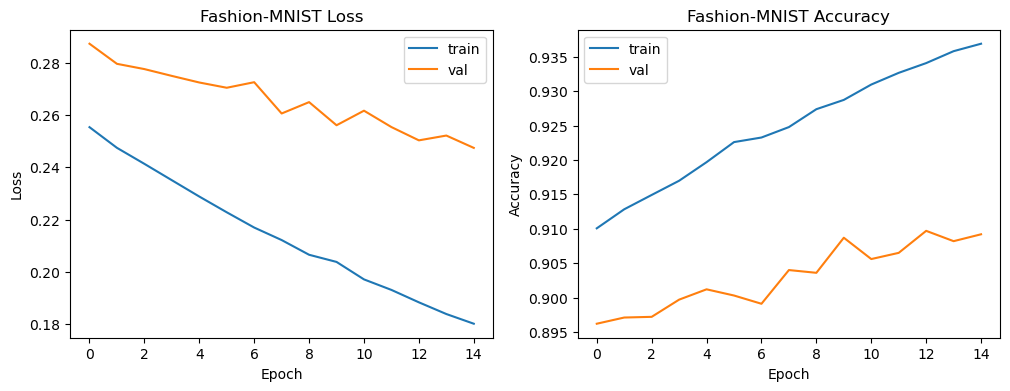

In [161]:
# Display best hyperparameters
best_hyperparameters = tuner.get_best_hyperparameters()[0]
print(best_hyperparameters.values)

# Retrain for history
history = best_model.fit(
    X_train_minist, y_train_mnist,
    validation_data=(X_test_mnist, y_test_mnist),
    epochs=15,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


# Plot history loss and accuracy
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Fashion-MNIST Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Fashion-MNIST Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


Reloading Tuner from iris_tuning\iris_classification\tuner0.json


c:\Anaconda\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 957ms/step - accuracy: 1.0000 - loss: 0.1904
Best model accuracy: 100.00%
Epoch 1/15


c:\Anaconda\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8667 - loss: 0.3157 - val_accuracy: 1.0000 - val_loss: 0.1829
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8917 - loss: 0.2879 - val_accuracy: 1.0000 - val_loss: 0.1726
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9250 - loss: 0.2411 - val_accuracy: 1.0000 - val_loss: 0.1663
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9000 - loss: 0.2618 - val_accuracy: 1.0000 - val_loss: 0.1584
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8667 - loss: 0.2561 - val_accuracy: 1.0000 - val_loss: 0.1503
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8917 - loss: 0.2318 - val_accuracy: 1.0000 - val_loss: 0.1424
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8917 - loss: 0.2356 - val_accuracy: 1.0000 - val_loss: 0.1372
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8750 - loss: 0.2334 - val_accuracy: 1.0000 - val_loss: 0.1330
Epoch 9/15


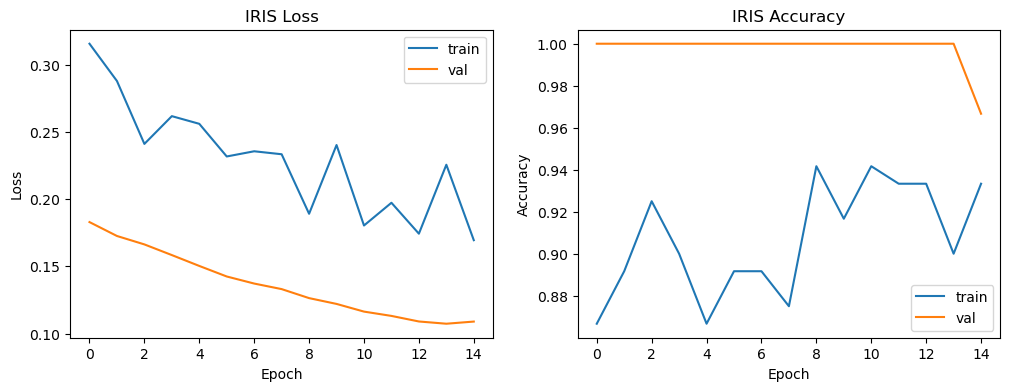

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 0.1073
Best model accuracy: 100.00%


In [152]:
from sklearn.datasets import load_iris

# ------------------------
# Load and preprocess IRIS
# ------------------------
iris = load_iris()
X_iris = iris.data
y_iris = iris.target.reshape(-1,1)  # Keras requires 2D labels

# One-hot encode
encoder = OneHotEncoder(sparse_output=False)
y_iris_encoded = encoder.fit_transform(y_iris)

# Split
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris_encoded, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_iris = scaler.fit_transform(X_train_iris)
X_test_iris = scaler.transform(X_test_iris)
# Build tunable model
def build_iris_model(hp):
    model = Sequential()
    
    model.add(Dense(
        units=hp.Int('units_1', min_value=8, max_value=32, step=8),  # Hidden layer
        activation=hp.Choice('activation_1', ['relu', 'tanh']), # Activation
    ))
    
    model.add(Dropout(hp.Float('dropout', 0.0, 0.3, step=0.1)))
    model.add(Dense(3, activation='softmax'))
    
    lr = hp.Choice('learning_rate', [1e-2, 5e-3, 1e-3])
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ModelCheckpoint('iris_best_model.keras', save_best_only=True)
]

# ------------------------
# Keras Tuner
# ------------------------
tuner = kt.RandomSearch(
    build_iris_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='iris_tuning',
    project_name='iris_classification'
)

tuner.search(
    X_train_iris, y_train_iris,
    epochs=20,
    validation_data=(X_test_iris, y_test_iris),
    batch_size=16,
    callbacks=callbacks,
    verbose=2
)

iris_best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate
loss, acc = iris_best_model.evaluate(X_test_iris, y_test_iris)
print(f"Best model accuracy: {acc*100:.2f}%")

# Save weights
iris_best_model.save_weights("iris_weights.weights.h5")

# Save full model
iris_best_model.save("iris_model.keras")

# Load weights
iris_best_model.load_weights('iris_weights.weights.h5')

# Load full model
loaded_model = load_model('iris_model.keras')

# Train it again to get history 
history_iris = iris_best_model.fit(
    X_train_iris, y_train_iris,
    validation_data=(X_test_iris, y_test_iris),
    epochs=15,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)


history_iris = iris_best_model.history # Keras Tuner stores training history here

if history_iris is not None:
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,2,1)
    plt.plot(history_iris.history['loss'], label='train')
    plt.plot(history_iris.history['val_loss'], label='val')
    plt.title('IRIS Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(history_iris.history['accuracy'], label='train')
    plt.plot(history_iris.history['val_accuracy'], label='val')
    plt.title('IRIS Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.show()


    # evaluate
    loss, acc = iris_best_model.evaluate(X_test_iris, y_test_iris)
    print(f"Best model accuracy: {acc*100:.2f}%")


## Regression Probelm 

In [37]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

# Load dataset
data = fetch_california_housing()
X_cal = pd.DataFrame(data.data, columns=data.feature_names)
y_cal = pd.Series(data.target, name='MedHouseVal')

print(X_cal.shape, y_cal.shape)  # Features and target

(20640, 8) (20640,)


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split: 80% train, 20% test
X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=42
)

print(y_train_cal[:5])

# Scale features 
scaler = StandardScaler()
X_train_cal = scaler.fit_transform(X_train_cal)
X_test_cal = scaler.transform(X_test_cal)

# Reshape target 
# keras expects a 2D array
y_train_cal = y_train_cal.values.reshape(-1, 1)
y_test_cal = y_test_cal.values.reshape(-1, 1)

print(X_train_cal.shape, y_train_cal.shape)
print(X_test_cal.shape, y_test_cal.shape)

print(y_train_cal[:5])


14196    1.030
8267     3.821
17445    1.726
14265    0.934
2271     0.965
Name: MedHouseVal, dtype: float64
(16512, 8) (16512, 1)
(4128, 8) (4128, 1)
[[1.03 ]
 [3.821]
 [1.726]
 [0.934]
 [0.965]]


### Build and train a neural network for price prediction. Tune the hyperparameters and discuss the results.


In [50]:
# Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt


In [51]:
# Load dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='MedHouseVal')

print(X.shape, y.shape)  # Features and target


(20640, 8) (20640,)


In [ ]:
# Split data into train/test sets

X_train_minist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_minist = scaler.fit_transform(X_train_minist)
X_test_mnist = scaler.transform(X_test_mnist)

# Reshape targets to 2D array (required for Keras)
y_train_mnist = y_train_mnist.values.reshape(-1, 1)
y_test_mnist = y_test_mnist.values.reshape(-1, 1)


In [57]:
# Build model function for hyperparameter tuning
def build_model(hp):
    model = Sequential()
    
    # First hidden layer
    model.add(Dense(
        units=hp.Int('units_1', 32, 256, step=32),
        activation='relu',
        #input_shape=(X_train.shape[1],)
    ))
    
    # Second layer
    if hp.Boolean('second_layer'):
        model.add(Dense(
            units=hp.Int('units_2', 32, 256, step=32),
            activation='relu'
        ))
    
    # Dropout
    model.add(Dropout(hp.Float('dropout', 0.0, 0.5, step=0.1)))
    
    # Output layer for regression
    model.add(Dense(1, activation='linear'))
    
    # Compile model
    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='mse',
                  metrics=['mae'])
    return model


In [58]:
# Set up Keras Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_mae',   # Minimise validation MAE
    max_trials=10,
    executions_per_trial=1,
    directory='housing_tuner',
    project_name='california_price'
)


In [ ]:
# Hyperparameter search with callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

tuner.search(
    X_train_minist, y_train_mnist,
    epochs=20,             # Upper limit, early stopping will stop earlier
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Trial 10 Complete [00h 00m 24s]
val_mae: 0.41661521792411804

Best val_mae So Far: 0.36021292209625244
Total elapsed time: 00h 07m 51s


In [61]:
# Retrieve best model and hyperparameters

best_model_cal = tuner.get_best_models(1)[0]
best_hp_cal = tuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters:")
for key in best_hp_cal.values.keys():
    print(f"{key}: {best_hp_cal.get(key)}")


Best Hyperparameters:
units_1: 192
second_layer: True
dropout: 0.1
learning_rate: 0.01
units_2: 32


c:\Anaconda\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Rebuild and retrain model fully
final_model_cal = tuner.hypermodel.build(best_hp_cal)

history = final_model_cal.fit(
    X_train_minist, y_train_mnist,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.5634 - mae: 0.5290 - val_loss: 0.5021 - val_mae: 0.5443
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4261 - mae: 0.4635 - val_loss: 0.3851 - val_mae: 0.4509
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3883 - mae: 0.4412 - val_loss: 0.3881 - val_mae: 0.4332
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3665 - mae: 0.4259 - val_loss: 0.3734 - val_mae: 0.4324
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3777 - mae: 0.4387 - val_loss: 0.3510 - val_mae: 0.4154
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3549 - mae: 0.4243 - val_loss: 0.3457 - val_mae: 0.4138
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3643 - mae: 0.4216 - val_loss: 0.3492 - val_mae: 0.4148
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3422 - mae: 0.4132 - val_loss: 0.3406 - val_mae: 0.4088
Epoch 9/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step

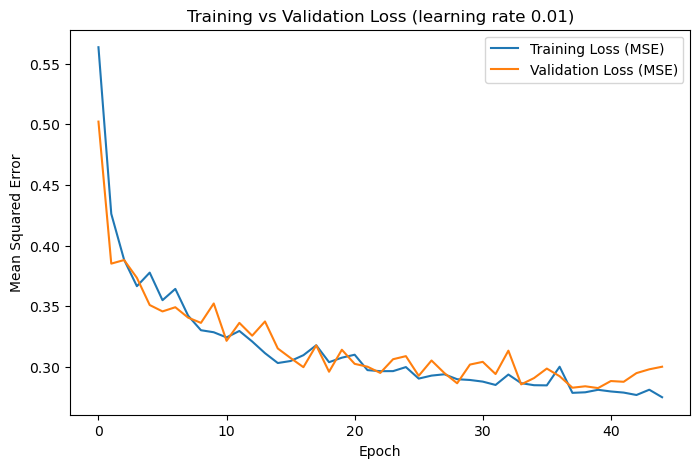

In [80]:
# Visualise training and validation loss
history_dict = history.history

plt.figure(figsize=(8,5))
plt.plot(history_dict['loss'], label='Training Loss (MSE)')
plt.plot(history_dict['val_loss'], label='Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Validation Loss (learning rate 0.01)')
plt.legend()
plt.show()

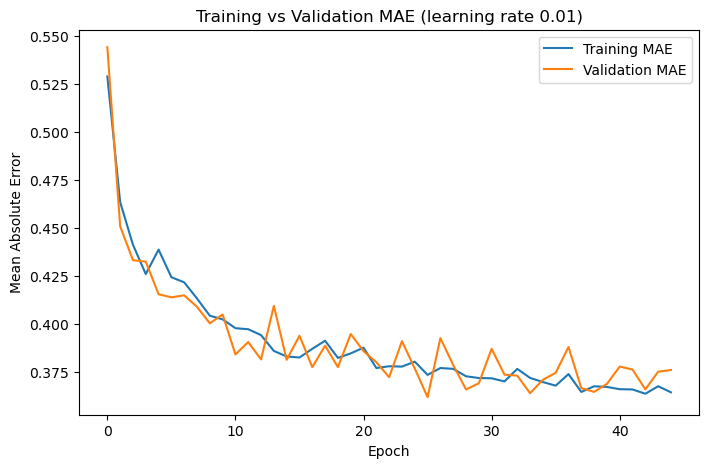

In [79]:
# Plot training and validation MAE
plt.figure(figsize=(8,5))
plt.plot(history_dict['mae'], label='Training MAE')
plt.plot(history_dict['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.title('Training vs Validation MAE (learning rate 0.01)')
plt.legend()
plt.show()

In [ ]:
# Evaluate on test data
test_loss, test_mae = final_model_cal.evaluate(X_test_mnist, y_test_mnist, verbose=1)
print(f"Test MSE: {test_loss:.3f}")
print(f"Test MAE: {test_mae:.3f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2780 - mae: 0.3621
Test MSE: 0.278
Test MAE: 0.362


Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.0322 - mae: 0.6908 - val_loss: 0.4985 - val_mae: 0.4960
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4608 - mae: 0.4846 - val_loss: 0.4260 - val_mae: 0.4655
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4305 - mae: 0.4647 - val_loss: 0.4118 - val_mae: 0.4517
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4036 - mae: 0.4486 - val_loss: 0.4009 - val_mae: 0.4573
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3881 - mae: 0.4424 - val_loss: 0.3793 - val_mae: 0.4296


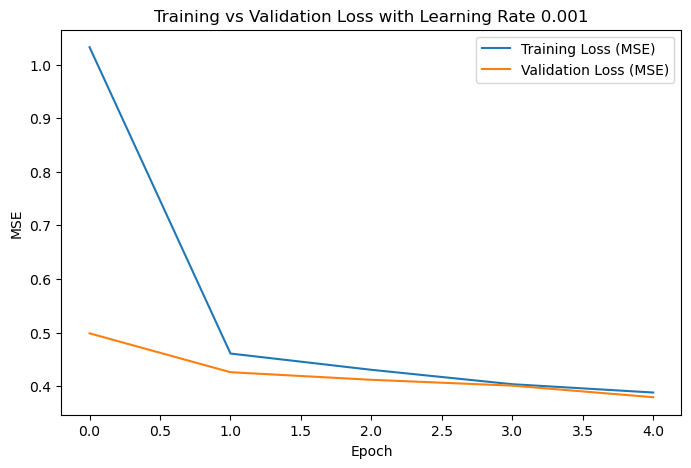

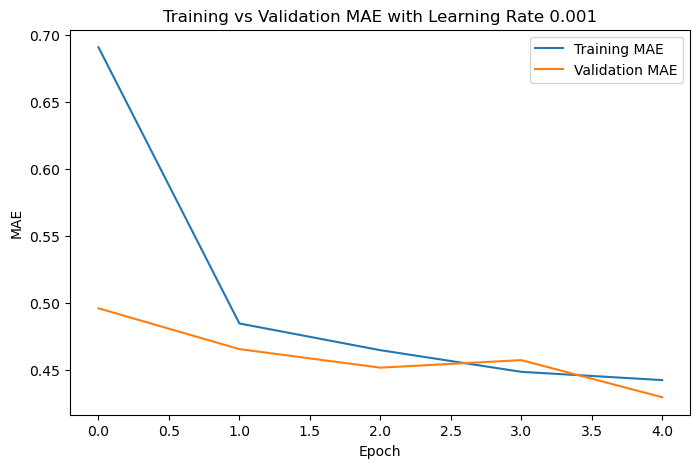

In [ ]:
# Change learning rate 
final_model_lr = Sequential()
final_model_lr.add(Dense(192, activation='relu', input_shape=(X_train_minist.shape[1],)))
final_model_lr.add(Dense(32, activation='relu'))
final_model_lr.add(Dropout(0.1))
final_model_lr.add(Dense(1, activation='linear'))

# Compile with new learning rate
final_model_lr.compile(optimizer=Adam(learning_rate=0.001),  # changed from 0.01 to 0.001
                       loss='mse',
                       metrics=['mae'])

# Train
history_lr = final_model_lr.fit(
    X_train_minist, y_train_mnist,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history_lr.history['loss'], label='Training Loss (MSE)')
plt.plot(history_lr.history['val_loss'], label='Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training vs Validation Loss with Learning Rate 0.001')
plt.legend()
plt.show()

# Plot MAE
plt.figure(figsize=(8,5))
plt.plot(history_lr.history['mae'], label='Training MAE')
plt.plot(history_lr.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE with Learning Rate 0.001')
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Callback to save weights
checkpoint = ModelCheckpoint('california.weights.h5', save_best_only=True, save_weights_only=True)

# Train with checkpoint callback
final_model_cal.fit(
    X_train_minist, y_train_mnist,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

# Load weights into same model architecture
final_model_lr.load_weights('california.weights.h5')


Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2791 - mae: 0.3649 - val_loss: 0.2868 - val_mae: 0.3728
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2814 - mae: 0.3689 - val_loss: 0.2930 - val_mae: 0.3676
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2784 - mae: 0.3673 - val_loss: 0.3340 - val_mae: 0.3910
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2853 - mae: 0.3721 - val_loss: 0.2937 - val_mae: 0.3623
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2814 - mae: 0.3665 - val_loss: 0.2859 - val_mae: 0.3733


In [ ]:
# Save entire model
final_model_cal.save('california_housing_model_lr_0.01.keras')
final_model_lr.save('california_housing_model.keras')

# Load model
loaded_model = tf.keras.models.load_model('california_housing_model.keras')

load_model_2 = tf.keras.models.load_model('california_housing_model_lr_0.01.keras')

# Evaluate loaded model
test_loss, test_mae = load_model_2.evaluate(X_test_mnist, y_test_mnist)
print(f"Loaded Model Test MSE lr 0.01: {test_loss:.3f}")
print(f"Loaded Model Test MAE lr 0.01: {test_mae:.3f}")

# Evaluate loaded model
test_loss, test_mae = loaded_model.evaluate(X_test_mnist, y_test_mnist)
print(f"Loaded Model Test MSE lr 0.001: {test_loss:.3f}")
print(f"Loaded Model Test MAE lr 0.001: {test_mae:.3f}")


c:\Anaconda\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2861 - mae: 0.3703
Loaded Model Test MSE lr 0.01: 0.286
Loaded Model Test MAE lr 0.01: 0.370
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2975 - mae: 0.3725
Loaded Model Test MSE lr 0.001: 0.298
Loaded Model Test MAE lr 0.001: 0.373
